In [1]:
# analysis
import numpy as np
import pandas as pd 

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# single-cell
import scanpy as sc
import liana as li
import maboss

ipylab module is not installed, menus and toolbar are disabled.


Basic data loading tets

In [2]:
# free data (3k PBMC cells)
adata = sc.datasets.pbmc3k()

In [3]:
# Wczytanie danych
adata = sc.datasets.pbmc3k()

# Wstępna normalizacja
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# ZAPISANIE DO .raw - to rozwiązuje Twój błąd!
adata.raw = adata

# Aby mieć po czym grupować ('louvain'), musimy zredukować wymiary i sklastrować dane
sc.pp.pca(adata)
sc.pp.neighbors(adata)
# IMPORTANT we need to use LEIDEN not 
sc.tl.leiden(adata)

# Teraz uruchamiamy LIANA+]

li.mt.rank_aggregate(adata, groupby='leiden', return_all_lrs=True)

ccc_results = adata.uns['liana_res']
print(ccc_results.head())

/tmp/ipykernel_13216/1776120498.py:15: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
/home/maxi7524/micromamba/envs/sc_env/lib/python3.12/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
/home/maxi7524/micromamba/envs/sc_env/lib/python3.12/site-packages/liana/method/_pipe_utils/_pre.py:146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
/home/maxi7524/micromamba/envs/sc_env/lib/python3.12/site-packages/liana/method/_pipe_utils/_pre.py:149: FutureWarning: The default of observed=False is deprecated and w

      source target ligand_complex receptor_complex  lr_means  \
58914      3      8         S100A9            ITGB2  3.493192   
55873      3      6         S100A9             CD68  3.410479   
57393      3      7         S100A9             CD68  3.401547   
57394      3      7         S100A9            ITGB2  3.275019   
58909      3      8         S100A8            ITGB2  3.241278   

       cellphone_pvals  expr_prod  scaled_weight  lr_logfc  spec_weight  \
58914              0.0  10.304152       1.567280  3.084493     0.068996   
55873              0.0   9.498365       1.829962  3.201487     0.113388   
57393              0.0   9.411355       1.820177  3.197615     0.112349   
57394              0.0   8.178726       1.362322  2.621409     0.054764   
58909              0.0   9.238342       1.632559  3.245403     0.085683   

        lrscore  specificity_rank  magnitude_rank  
58914  0.968880      2.613269e-07    5.820697e-09  
55873  0.967629      4.868351e-08    2.328239e-08  
57

In [4]:
ccc_results

,source,target,ligand_complex,receptor_complex,lr_means,cellphone_pvals,expr_prod,scaled_weight,lr_logfc,spec_weight,lrscore,specificity_rank,magnitude_rank
58914,3,8,S100A9,ITGB2,3.493192,0.0,10.304152,1.567280,3.084493,0.068996,0.968880,2.613269e-07,5.820697e-09
55873,3,6,S100A9,CD68,3.410479,0.0,9.498365,1.829962,3.201487,0.113388,0.967629,4.868351e-08,2.328239e-08
57393,3,7,S100A9,CD68,3.401547,0.0,9.411355,1.820177,3.197615,0.112349,0.967485,5.398794e-08,3.637843e-08
57394,3,7,S100A9,ITGB2,3.275019,0.0,8.178726,1.362322,2.621409,0.054764,0.965203,2.613269e-07,9.312642e-08
58909,3,8,S100A8,ITGB2,3.241278,0.0,9.238342,1.632559,3.245403,0.085683,0.967192,2.613269e-07,1.178621e-07
...,...,...,...,...,...,...,...,...,...,...,...,...,...
20,0,0,ADAM15,ITGAV,0.124471,1.0,0.015490,-0.776023,-2.815083,0.000421,0.546926,1.000000e+00,1.000000e+00
19,0,0,ADAM15,ITGA5,0.124471,1.0,0.015490,-0.776023,-2.815083,0.000421,0.546926,1.000000e+00,1.000000e+00
18,0,0,ADAM12,SDC4,0.124471,1.0,0.015490,-0.776023,-2.815083,0.000421,0.546926,1.000000e+00,1.000000e+00
17,0,0,ADAM12,ITGB1,0.124471,1.0,0.015490,-0.776023,-2.815083,0.000421,0.546926,1.000000e+00,1.000000e+00


Minimalny pipeline w pythonie do pymyboss (potrzeba załadować jakiś model komórkowy)

In [7]:
import maboss
import pandas as pd

# 1. Wczytanie modelu wewnątrzkomórkowego (np. sieci regulacji genów dla naszej komórki)
# Plik .bnd definiuje logikę, a .cfg parametry symulacji
sim = maboss.load("moj_model.bnd", "moj_model.cfg")

# Załóżmy, że LIANA+ dała nam takie wagi (prawdopodobieństwa) obecności sygnału w 3 punktach w czasie:
# np. stężenie cytokiny TNF w środowisku wokół naszej komórki
time_series_environment = [0.1, 0.8, 0.3] 

# 2. Pętla czasowa symulująca interakcję ze środowiskiem
czas_kroku_dt = 10 

for t, external_signal in enumerate(time_series_environment):
    print(f"--- Krok czasowy {t} ---")
    
    # a) Aktualizacja informacji ze środowiska (wymuszamy prawdopodobieństwo aktywacji receptora)
    # [prawdopodobieństwo_0, prawdopodobieństwo_1]
    sim.network.set_istate('Receptor_TNF', [1 - external_signal, external_signal])
    
    # b) Uruchomienie symulacji na czas dt
    sim.update_parameters(max_time=czas_kroku_dt)
    result = sim.run()
    
    # c) Odczytanie stanu końcowego komórki
    last_states = result.get_last_states_probtraj()
    
    # d) Magia integracji: Używamy stanu końcowego jako stanu początkowego na kolejny krok!
    # Pobieramy prawdopodobieństwa stanów węzłów z końca symulacji
    # i nadpisujemy nimi model na następny obieg pętli (z wyjątkiem receptora, który sterowany jest z zewnątrz)
    for node in sim.network.keys():
        if node != 'Receptor_TNF':
            # Uproszczenie: w prawdziwym kodzie mapujesz wyciągnięte prawdopodobieństwo z tabeli last_states
            prob_active = get_node_prob_from_last_state(last_states, node) 
            sim.network.set_istate(node, [1 - prob_active, prob_active])

    print("Symulacja kroku zakończona. Komórka zaadaptowała się do nowego środowiska.")

FileNotFoundError: [Errno 2] No such file or directory: 'moj_model.bnd'

### Protokół single cell

Zakładamy, że mamy wygenerwanie poprawnie macierze w formacie .mtx lub .h5ad

In [24]:
# ----- Łączenie danych ----- #

import scanpy as sc
import scipy.sparse as sp
import anndata as ad
import numpy as np
# # W rzeczywistości wczytujemy dane z dysku np.:
# adata_ctrl = sc.read_10x_mtx('data/control/')
# adata_stim = sc.read_10x_mtx('data/stimulated/')

# Na potrzeby naszego ćwiczenia użyjemy wbudowanego zbioru i go podzielimy/zmodyfikujemy
adata_ctrl = sc.datasets.pbmc3k()
adata_ctrl.obs['condition'] = 'Control'

# Tworzymy "sztuczną" drugą próbę (np. po stymulacji lekami)
adata_stim = sc.datasets.pbmc3k()
adata_stim.obs['condition'] = 'Stimulated'
# Sztuczna zmiana dla zilustrowania zróżnic w późniejszych analizach
# UWAGA: tutaj mamy specjalny format rzadkich macierzy 
adata_stim.X = sp.csr_matrix(adata_stim.X.multiply(np.random.uniform(0.8, 1.2, size=adata_stim.X.shape)))


# ŁĄCZENIE (Concatenation) - to najważniejszy krok przy wielu próbach
# outer join zapewnia, że jeśli w jednej próbie gen nie uległ ekspresji, zostanie wypełniony zerami
adata = ad.concat([adata_ctrl, adata_stim], label='batch', keys=['ctrl', 'stim'], join='outer')
adata.obs_names_make_unique() # Zabezpieczenie przed dublowaniem się kodów kreskowych komórek

print(adata_ctrl)
print(adata)
# Zobaczysz wymiary: n_cells x n_genes oraz zmienne w adata.obs: 'condition', 'batch'

AnnData object with n_obs × n_vars = 2700 × 32738
    obs: 'condition'
    var: 'gene_ids'
AnnData object with n_obs × n_vars = 5400 × 32738
    obs: 'condition', 'batch'


/home/maxi7524/micromamba/envs/sc_env/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.


In [ ]:
# ---- Kontrola jakości ---- # 
# 1. Oznaczenie genów mitochondrialnych (i opcjonalnie rybosomalnych)
# W przypadku ludzkich genów zaczynają się one od 'MT-'
adata.var['mt'] = adata.var_names.str.startswith('MT-')
# W przypadku myszy byłoby to 'mt-'

# 2. Obliczenie statystyk QC
# scanpy automatycznie obliczy n_genes_by_counts, total_counts i pct_counts_mt
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

# 3. Zapiszmy stan przed filtrowaniem, żeby zobaczyć, ile odrzuciliśmy
n_cells_raw = adata.n_obs

# 4. Filtrowanie (Twarde progi - w prawdziwych badaniach dobierasz je na podstawie wykresów)
# Minimalna liczba genów (usuwa puste krople i szczątki komórkowe)
sc.pp.filter_cells(adata, min_genes=200)

# Maksymalna liczba genów (usuwa potencjalne dublety - komórki o podejrzanie bogatym transkryptomie)
adata = adata[adata.obs.n_genes_by_counts < 2500, :]

# Frakcja mitochondrialna (zwykle 5-10% dla zdrowych PBMC, ale dla guzów może to być nawet 20-30%)
adata = adata[adata.obs.pct_counts_mt < 5, :]

# 5. Filtrowanie genów
# Usuwamy geny, które ulegają ekspresji w mniej niż np. 3 komórkach (totalny szum, nie przydadzą się do żadnej statystyki)
sc.pp.filter_genes(adata, min_cells=3)

print(f"Liczba komórek przed: {n_cells_raw}")
print(f"Liczba komórek po QC: {adata.n_obs}")

Liczba komórek przed: 5400
Liczba komórek po QC: 5278


/home/maxi7524/micromamba/envs/sc_env/lib/python3.12/site-packages/scanpy/preprocessing/_simple.py:278: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.


In [26]:
# ---- Normalizacja oraz wykrywanie wysoce zmiennych genów ---- # 

# 1. Zachowanie surowych danych (Raw counts)
# Bardzo ważne: LIANA+ i testy różnicowej ekspresji często wymagają surowych zliczeń całkowitych!
adata.raw = adata.copy()

# 2. Normalizacja (do 10,000 zliczeń na komórkę)
sc.pp.normalize_total(adata, target_sum=1e4)

# 3. Logarytmizacja
sc.pp.log1p(adata)

# 4. Identyfikacja HVG
# Używamy metody 'seurat' (wymaga danych zlogarytmowanych) lub 'cell_ranger'
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)

# Wizualizacja HVG (opcjonalnie)
# sc.pl.highly_variable_genes(adata)

# 5. Filtrowanie macierzy do HVG
# Robimy kopię lub pracujemy na widoku, aby nie stracić reszty genów
adata_hvg = adata[:, adata.var.highly_variable].copy()

In [28]:
# ---- Wycieszenie genów mitochondrioalnych żeby nie wprowadzały szumu ----- 
# Regresja efektów technicznych
sc.pp.regress_out(adata_hvg, ['total_counts', 'pct_counts_mt'])

# Skalowanie (Unit variance, zero mean)
sc.pp.scale(adata_hvg, max_value=10)

... storing 'condition' as categorical
/home/maxi7524/micromamba/envs/sc_env/lib/python3.12/site-packages/scanpy/preprocessing/_simple.py:657: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 1, 'A', False, aligned=True), Array(float64, 2, 'C', False, aligned=True))
/home/maxi7524/micromamba/envs/sc_env/lib/python3.12/site-packages/scanpy/preprocessing/_simple.py:657: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 1, 'A', False, aligned=True), Array(float64, 2, 'C', False, aligned=True))


/tmp/ipykernel_13216/3077661497.py:14: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.


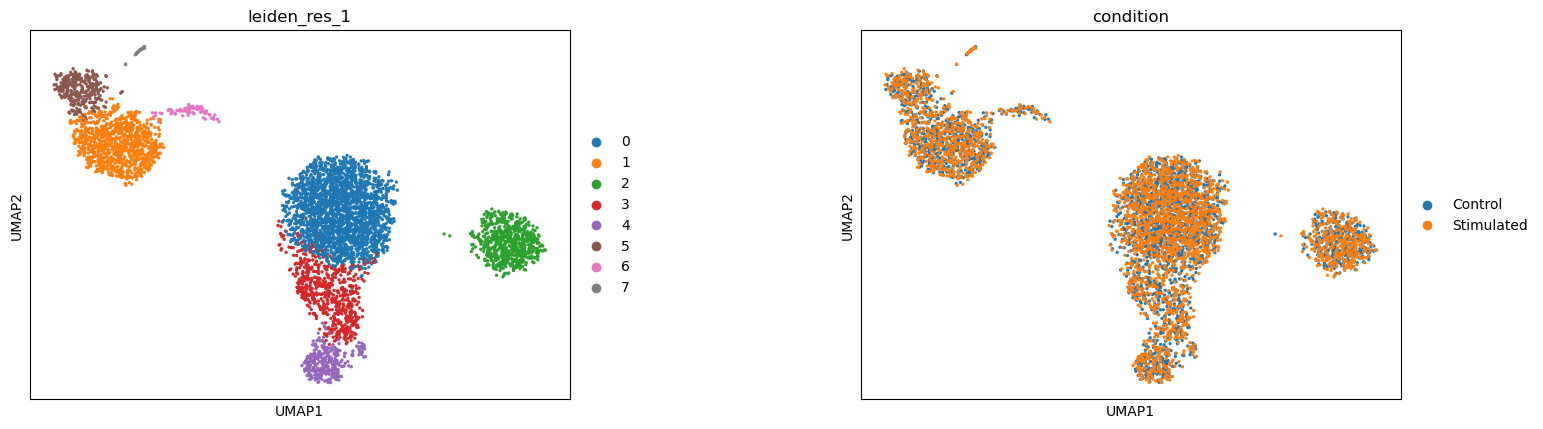

In [29]:
# ---- redukcja wymiarowości i redukcja grafu ----
# 1. PCA
# n_comps określa liczbę wymiarów, które zachowujemy (zwykle 30-50)
sc.tl.pca(adata_hvg, n_comps=50, svd_solver='arpack')

# 2. Budowa grafu sąsiedztwa (KNN)
# n_neighbors to liczba sąsiadów (zwykle 10-15). Większa liczba = bardziej globalna struktura.
# use_rep='X_pca' mówi algorytmowi, by patrzył na składowe PCA, a nie na surowe geny.
sc.pp.neighbors(adata_hvg, n_neighbors=15, n_pcs=40)

# 3. Klastrowanie LEIDEN
# resolution=1.0 to standardowy start. Zmieniamy go zależnie od potrzebnej ziarnistości.
# flavor='vtraag' lub 'igraph' - wymaga zainstalowanych bibliotek, o których rozmawialiśmy.
sc.tl.leiden(adata_hvg, resolution=1.0, key_added='leiden_res_1')

# 4. Wizualizacja UMAP (Uniform Manifold Approximation and Projection)
# UMAP służy tylko do wizualizacji grafu w 2D, nie używamy go do klastrowania!
sc.tl.umap(adata_hvg)

# Wizualizacja wyników
sc.pl.umap(adata_hvg, color=['leiden_res_1', 'condition'], wspace=0.4)

In [30]:
# ---- porządkowanie wielu agregacji ----
import liana as li

# 1. Podstawowa analiza CCC dla całego zbioru
# Metoda rank_aggregate wykonuje konsensus wielu metod
li.mt.rank_aggregate(
    adata, 
    groupby='leiden', 
    resource_name='consensus', # Używa ujednoliconej bazy OmniPath
    expr_prop=0.1,             # Minimum 10% komórek w klastrze musi mieć ekspresję L lub R
    verbose=True
)

# Wyniki są zapisane w adata.uns['liana_res']
df_res = adata.uns['liana_res']

# 2. Porównanie warunków (Control vs Stimulated)
# LIANA+ pozwala na łatwe filtrowanie wyników per warunek
li.mt.rank_aggregate(
    adata,
    groupby='leiden',
    base_iterable=adata.obs['condition'].unique(), # Iteruje po warunkach
    inplace=True
)

Using resource `consensus`.
Using `.raw`!
/home/maxi7524/micromamba/envs/sc_env/lib/python3.12/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
Make sure that normalized counts are passed!


AssertionError: `leiden` not found in `adata.obs.columns`.